#### Libraries

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency



#### Loading Dataframes

In [3]:
df_demo = pd.read_csv('data/df_final_demo.txt')
df_final_experiment = pd.read_csv('data/df_final_experiment_clients.txt')
df_final_web_1 = pd.read_csv('data/df_final_web_data_pt_1.txt')
df_final_web_2 = pd.read_csv('data/df_final_web_data_pt_2.txt')

In [4]:
df_demo

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0
...,...,...,...,...,...,...,...,...,...
70604,7993686,4.0,56.0,38.5,U,3.0,1411062.68,5.0,5.0
70605,8981690,12.0,148.0,31.0,M,2.0,101867.07,6.0,6.0
70606,333913,16.0,198.0,61.5,F,2.0,40745.00,3.0,3.0
70607,1573142,21.0,255.0,68.0,M,3.0,475114.69,4.0,4.0


In [5]:
df_final_experiment

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control
...,...,...
70604,2443347,NaN
70605,8788427,NaN
70606,266828,NaN
70607,1266421,NaN


In [6]:
df_final_web_1

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
...,...,...,...,...,...
343136,2443347,465784886_73090545671,136329900_10529659391_316129,confirm,2017-03-31 15:15:46
343137,2443347,465784886_73090545671,136329900_10529659391_316129,step_3,2017-03-31 15:14:53
343138,2443347,465784886_73090545671,136329900_10529659391_316129,step_2,2017-03-31 15:12:08
343139,2443347,465784886_73090545671,136329900_10529659391_316129,step_1,2017-03-31 15:11:37


In [7]:
df_final_web_2

,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58
...,...,...,...,...,...
412259,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:46:10
412260,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:45:29
412261,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24 18:44:51
412262,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:44:34


In [8]:
# Merge the two web dataframes into one
df_final_web_1_and_2 = pd.concat([df_final_web_1, df_final_web_2], ignore_index=True)

In [9]:
df_final_web_1_and_2

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
...,...,...,...,...,...
755400,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:46:10
755401,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:45:29
755402,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24 18:44:51
755403,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:44:34


# Phase 1 — EDA & Data Cleaning



#### Remove duplicates

Let's remove duplicates from all dfs before continuing

In [10]:
df_demo = df_demo.drop_duplicates()
df_final_experiment = df_final_experiment.drop_duplicates()
df_final_web_1_and_2 = df_final_web_1_and_2.drop_duplicates()


In [11]:
df_demo

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0
...,...,...,...,...,...,...,...,...,...
70604,7993686,4.0,56.0,38.5,U,3.0,1411062.68,5.0,5.0
70605,8981690,12.0,148.0,31.0,M,2.0,101867.07,6.0,6.0
70606,333913,16.0,198.0,61.5,F,2.0,40745.00,3.0,3.0
70607,1573142,21.0,255.0,68.0,M,3.0,475114.69,4.0,4.0


In [12]:
df_final_experiment

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control
...,...,...
70604,2443347,NaN
70605,8788427,NaN
70606,266828,NaN
70607,1266421,NaN


In [13]:
df_final_web_1_and_2

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
...,...,...,...,...,...
755400,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:46:10
755401,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:45:29
755402,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24 18:44:51
755403,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:44:34


#### Nulls

In the dataframes, as per showed with 'Data Wrangler' extension, there are a lot of customers not assigned to groups and some nulls in the demo df. Let's explore that.

In [14]:
def null_report(df):
    '''Sum of null values and percentage of null values for each column in a dataframe.'''
    return pd.DataFrame({
        "column": df.columns,
        "nulls": df.isna().sum().values,
        "percent": (df.isna().mean() * 100).round(2).values
    })


In [15]:
nulls_demo = null_report(df_demo)
print("Nulls in df_demo:")
print(nulls_demo)
nulls_experiment = null_report(df_final_experiment)
print("\nNulls in df_final_experiment:")
print(nulls_experiment)
nulls_web_1_and_2 = null_report(df_final_web_1_and_2)
print("\nNulls in df_final_web_1_and_2:")
print(nulls_web_1_and_2)

Nulls in df_demo:
             column  nulls  percent
0         client_id      0     0.00
1    clnt_tenure_yr     14     0.02
2  clnt_tenure_mnth     14     0.02
3          clnt_age     15     0.02
4             gendr     14     0.02
5         num_accts     14     0.02
6               bal     14     0.02
7      calls_6_mnth     14     0.02
8     logons_6_mnth     14     0.02

Nulls in df_final_experiment:
      column  nulls  percent
0  client_id      0     0.00
1  Variation  20109    28.48

Nulls in df_final_web_1_and_2:
         column  nulls  percent
0     client_id      0      0.0
1    visitor_id      0      0.0
2      visit_id      0      0.0
3  process_step      0      0.0
4     date_time      0      0.0


As we can see not all clients are part of the experiment with an about 30% of them without group assigned

In [16]:
overview = pd.DataFrame({
    "column": df_final_experiment.columns,
    "not_nulls": df_final_experiment.notna().sum().values,
    "nulls": df_final_experiment.isna().sum().values
})

overview

,column,not_nulls,nulls
0,client_id,70609,0
1,Variation,50500,20109


So only 50K of the clients are part of the experiment. Being known that, the strategy that we will follow is to eliminate their records from everywhere first.

In [17]:
ids_to_exclude = df_final_experiment.loc[df_final_experiment["Variation"].isna(), "client_id"].unique()
print(ids_to_exclude)
print(len(ids_to_exclude)) #To verify the number of unique client_ids with null Variation values


[5459747 8031000 1847030 ...  266828 1266421 9895983]
20109


In [18]:
# Remove all rows in df1, df2, and df3 whose client_id is in bad_ids
# using the client IDs collected from the raw table with null values

df_demo_no_nulls = df_demo[~df_demo["client_id"].isin(ids_to_exclude)].copy()
df_final_experiment_no_nulls = df_final_experiment[~df_final_experiment["client_id"].isin(ids_to_exclude)].copy()
df_final_web_1_and_2_no_nulls = df_final_web_1_and_2[~df_final_web_1_and_2["client_id"].isin(ids_to_exclude)].copy()


In [19]:
df_final_experiment_no_nulls

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control
...,...,...
50495,393005,Control
50496,2908510,Control
50497,7230446,Test
50498,5230357,Test


So this matches with the previously 50K clients assigned

In [20]:
df_demo_no_nulls

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0
...,...,...,...,...,...,...,...,...,...
50495,1780858,21.0,262.0,68.5,M,3.0,372100.59,6.0,9.0
50496,6967120,21.0,260.0,68.5,M,3.0,4279873.38,6.0,9.0
50497,5826160,20.0,249.0,56.5,F,2.0,44837.16,2.0,5.0
50498,8739285,19.0,229.0,69.5,F,2.0,44994.24,1.0,4.0


It has some values missing. As it is a small percentage, let's drop them.

In [21]:
df_demo_no_nulls = df_demo_no_nulls.dropna(how="any")
df_demo_no_nulls

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0
...,...,...,...,...,...,...,...,...,...
50495,1780858,21.0,262.0,68.5,M,3.0,372100.59,6.0,9.0
50496,6967120,21.0,260.0,68.5,M,3.0,4279873.38,6.0,9.0
50497,5826160,20.0,249.0,56.5,F,2.0,44837.16,2.0,5.0
50498,8739285,19.0,229.0,69.5,F,2.0,44994.24,1.0,4.0


In [22]:
df_merged = df_demo_no_nulls.merge(
    df_final_experiment_no_nulls,
    on="client_id",
    how="inner"
)


In [23]:
df_final_web_1_and_2_no_nulls

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
...,...,...,...,...,...
755400,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:46:10
755401,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:45:29
755402,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24 18:44:51
755403,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:44:34


Finally, we keep only the web records whose  client_id  also appears in the experiment table. Any web row without a matching client in the experiment dataset is removed.

In [24]:
df_final_web_1_and_2_clean = df_final_web_1_and_2_no_nulls[
    df_final_web_1_and_2_no_nulls["client_id"].isin(df_final_experiment_no_nulls["client_id"])
].copy()

df_final_web_1_and_2_clean

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
...,...,...,...,...,...
637487,1574008,117364417_77840596075,528720790_71583064618_169151,start,2017-05-06 23:43:27
637532,2908510,814969699_90652851448,562606085_36368381773_92090,start,2017-05-10 22:57:17
637533,2908510,814969699_90652851448,562606085_36368381773_92090,step_2,2017-05-10 22:56:31
637534,2908510,814969699_90652851448,562606085_36368381773_92090,step_1,2017-05-10 22:56:23


In [25]:
print(df_final_web_1_and_2_no_nulls['client_id'].nunique())
print(df_final_web_1_and_2_clean['client_id'].nunique())

100048
50500


So the dataset has fallen 50% almost but we are having the same amount of unique csts ids.

### Casting date-time

In [26]:
df_final_web_1_and_2_clean["date_time"] = pd.to_datetime(df_final_web_1_and_2_clean["date_time"])
df_final_web_1_and_2_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 317235 entries, 0 to 637535
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   client_id     317235 non-null  int64         
 1   visitor_id    317235 non-null  object        
 2   visit_id      317235 non-null  object        
 3   process_step  317235 non-null  object        
 4   date_time     317235 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 14.5+ MB


## Exploring data

### Demographics

In [27]:
#This is as for now the only demographic that is categorical, so we will create a frequency table for it.
gender_table = pd.crosstab(df_merged["gendr"], columns="Count")
gender_table["%"] = (gender_table["Count"] / gender_table["Count"].sum() * 100).round(2)
gender_table


col_0,Count,%
gendr,,
F,16258,32.20
M,16947,33.57
U,17280,34.23
X,2,0.00


<Axes: ylabel='count'>

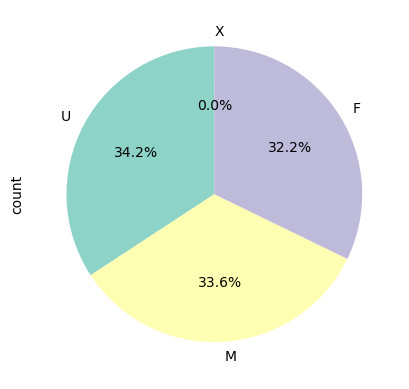

In [28]:
df_merged['gendr'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set3"))

In [29]:
df_merged.describe()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,5.048700e+04,50487.000000,50487.000000,50487.000000,50487.000000,5.048700e+04,50487.000000,50487.000000
mean,5.006180e+06,12.031810,150.416365,47.319795,2.254580,1.495168e+05,3.093272,6.131856
std,2.877445e+06,6.860326,81.945403,15.518616,0.533675,3.020390e+05,2.188009,2.175441
min,5.550000e+02,2.000000,33.000000,17.000000,1.000000,2.378944e+04,0.000000,3.000000
25%,2.515688e+06,6.000000,82.000000,33.500000,2.000000,3.987718e+04,1.000000,4.000000
50%,5.025043e+06,11.000000,136.000000,48.000000,2.000000,6.573433e+04,3.000000,6.000000
75%,7.477922e+06,16.000000,192.000000,59.500000,2.000000,1.399583e+05,5.000000,8.000000
max,9.999832e+06,55.000000,669.000000,96.000000,7.000000,1.632004e+07,6.000000,9.000000


In [30]:
# We are using median instead of mean because the data is skewed, and we want to avoid the influence of outliers. 


demo_table = (
    df_merged[df_merged["gendr"].isin(["F", "M", "U"])]
    .groupby("gendr")
    .agg(
        Clients=("client_id", "count"),
        Age_median=("clnt_age", "median"),
        Tenure_Years_Median=("clnt_tenure_yr", "median"),
        Tenure_Months_Median=("clnt_tenure_mnth", "median"),
        Balance_Median=("bal", "median"),
        Calls_6M_Median=("calls_6_mnth", "median"),
        Logons_6M_Median=("logons_6_mnth", "median"),
    )
    .round(2)
    .T
)

demo_table


gendr,F,M,U
Clients,16258.0,16947.00,17280.0
Age_median,52.0,50.50,39.5
Tenure_Years_Median,14.0,14.00,6.0
Tenure_Months_Median,173.0,173.00,77.0
Balance_Median,71135.4,88460.55,51430.5
Calls_6M_Median,2.0,4.00,3.0
Logons_6M_Median,6.0,7.00,6.0


-  Who are the primary clients using this online process? Are the primary clients younger or older, new or long-standing?


    The online process is mainly used by middle-aged, long-standing clients. On average, users are around 47 years old and have been with Vanguard for about 12 years, which suggests a mature and established customer base rather than a newly acquired one. They hold generally substantial balances, although the distribution is skewed by a smaller group of high-balance clients, and they show moderate platform engagement with around 6 logons and 3 support calls in the last six months. Gender distribution is fairly balanced across the main groups, but the  U  category stands out as a younger and less-tenured segment.

<Axes: xlabel='clnt_age', ylabel='Count'>

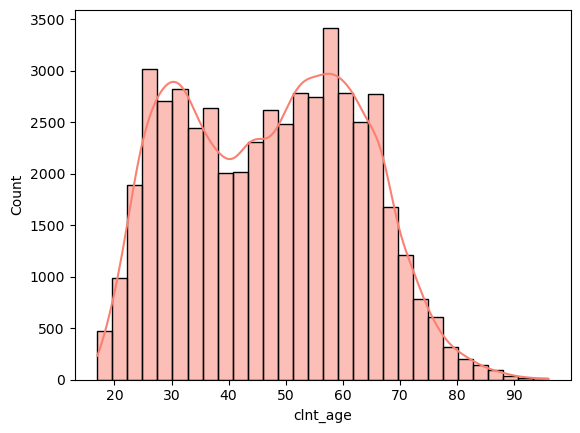

In [31]:
sns.histplot(df_merged['clnt_age'], kde=True, bins=30, color="salmon")

<Axes: xlabel='clnt_tenure_mnth', ylabel='Count'>

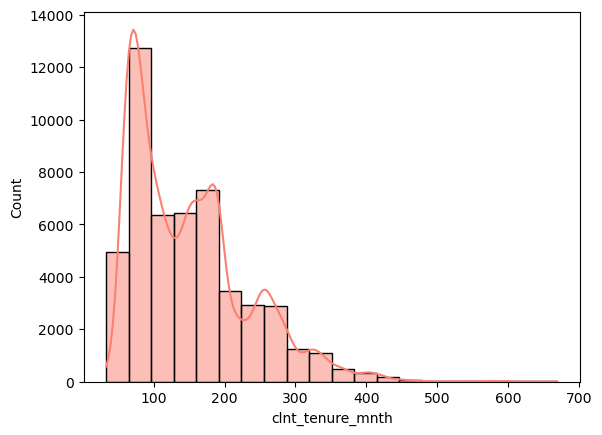

In [32]:
sns.histplot(df_merged['clnt_tenure_mnth'], kde=True, bins=20, color="salmon")

In [33]:
demo_table_with_variation = (
    df_merged[df_merged["gendr"].isin(["F", "M", "U"])]
    .groupby(["Variation", "gendr"])
    .agg(
        Clients=("client_id", "count"),
        Age_Median=("clnt_age", "median"),
        Tenure_Years_Median=("clnt_tenure_yr", "median"),
        Tenure_Months_Median=("clnt_tenure_mnth", "median"),
        Balance_Median=("bal", "median"),
        Calls_6M_Median=("calls_6_mnth", "median"),
        Logons_6M_Median=("logons_6_mnth", "median"),
    )
    .round(2)
    .T
)

demo_table_with_variation


Variation              Control                         Test                  
gendr                        F        M         U         F        M        U
Clients                7542.00   7970.0   8014.00   8716.00   8977.0   9266.0
Age_Median               52.00     50.5     40.00     51.50     50.0     39.5
Tenure_Years_Median      14.00     14.0      6.00     14.00     14.0      6.0
Tenure_Months_Median    173.00    174.0     77.00    172.00    173.0     77.0
Balance_Median        70795.61  90075.6  51541.92  71446.28  86797.8  51321.1
Calls_6M_Median           2.00      4.0      3.00      2.00      3.0      3.0
Logons_6M_Median          6.00      7.0      6.00      6.00      7.0      6.0

The Control and Test groups are broadly similar across age, tenure, balance, calls, and logons when broken down by gender. This suggests the experiment groups were reasonably balanced at the begining so we can compare them equally later on.

In [34]:
group_sizes = df_merged["Variation"].value_counts()
print(group_sizes)


Variation
Test       26961
Control    23526
Name: count, dtype: int64


/var/folders/b4/svxttqvs5zg_rg_drrxn_vf00000gn/T/ipykernel_87698/2732912408.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_merged, x='Variation', palette="Set3")


<Axes: xlabel='Variation', ylabel='count'>

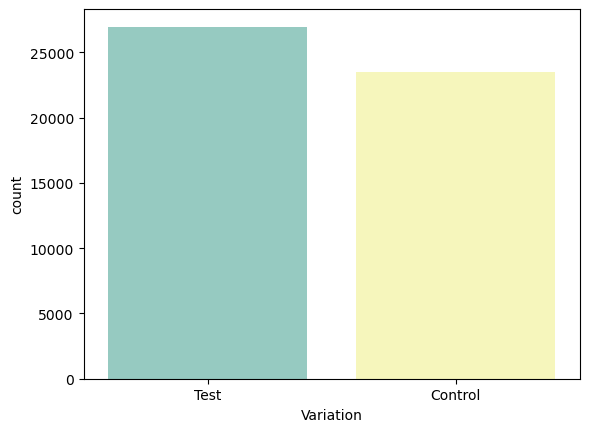

In [35]:
sns.countplot(data=df_merged, x='Variation', palette="Set3")

Test group seems to be around 3K bigger than control one, which might be important in the future when drawing conclusions

# Phase 2 — Performance Metrics



### Exploring customer journey

Let's explore to understand the customer journey in general as a process before deep diving further.

In [36]:
df_final_web_1_and_2_clean

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
...,...,...,...,...,...
637487,1574008,117364417_77840596075,528720790_71583064618_169151,start,2017-05-06 23:43:27
637532,2908510,814969699_90652851448,562606085_36368381773_92090,start,2017-05-10 22:57:17
637533,2908510,814969699_90652851448,562606085_36368381773_92090,step_2,2017-05-10 22:56:31
637534,2908510,814969699_90652851448,562606085_36368381773_92090,step_1,2017-05-10 22:56:23


In [37]:
web_merged = df_final_web_1_and_2_clean.merge(
    df_final_experiment_no_nulls,
    on="client_id",
    how="inner"
)

In [38]:
web_merged

,client_id,visitor_id,visit_id,process_step,date_time,Variation
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test
...,...,...,...,...,...,...
317230,1574008,117364417_77840596075,528720790_71583064618_169151,start,2017-05-06 23:43:27,Test
317231,2908510,814969699_90652851448,562606085_36368381773_92090,start,2017-05-10 22:57:17,Control
317232,2908510,814969699_90652851448,562606085_36368381773_92090,step_2,2017-05-10 22:56:31,Control
317233,2908510,814969699_90652851448,562606085_36368381773_92090,step_1,2017-05-10 22:56:23,Control


Independently of the groups, customers are navigating through a process that is start>step1>step2>step3>confirm. Some of them go back and forth in the process, this should be considered too.

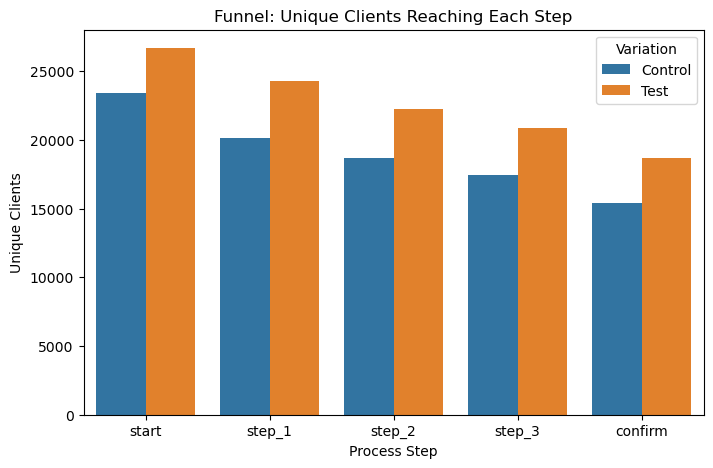

In [39]:
step_order = ["start", "step_1", "step_2", "step_3", "confirm"]

funnel = (
    web_merged.groupby(["Variation", "process_step"])["client_id"]
    .nunique()
    .reset_index(name="unique_clients")
)
funnel["process_step"] = pd.Categorical(funnel["process_step"], categories=step_order, ordered=True)
funnel = funnel.sort_values("process_step")

plt.figure(figsize=(8, 5))
sns.barplot(data=funnel, x="process_step", y="unique_clients", hue="Variation")
plt.title("Funnel: Unique Clients Reaching Each Step")
plt.xlabel("Process Step")
plt.ylabel("Unique Clients")
plt.show()

Potentially there are more Test than control users reaching each step as the group is bigger. Let's correct it

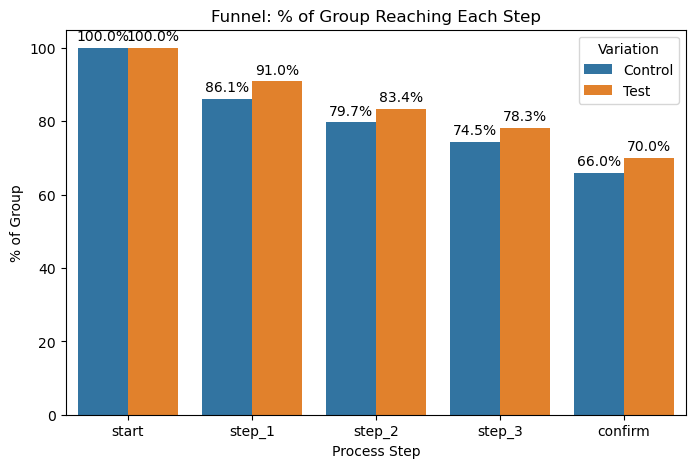

In [40]:
# Problem: Test has more total clients than Control, so raw counts aren't
# a fair comparison. We need each group's numbers as a % of THAT group's
# own starting cohort (the "start" step, which every client passes through).

# Step 1: get the max unique_clients per Variation (this is the "start" count,
# since it's the largest step for each group). .transform("max") returns this
# max value repeated on every row belonging to that Variation, without
# needing a separate merge step.
funnel["group_total"] = funnel.groupby("Variation")["unique_clients"].transform("max")

# Step 2: divide each row's count by its own group's total, times 100
funnel["pct_of_group"] = (funnel["unique_clients"] / funnel["group_total"]) * 100

# --- Plot ---
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=funnel, x="process_step", y="pct_of_group", hue="Variation")

# Add the % value on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Funnel: % of Group Reaching Each Step")
plt.xlabel("Process Step")
plt.ylabel("% of Group")
plt.ylim(0, 105)
plt.show()

## Success Indicators (KPIs)


Calculate at least:

- **Completion Rate**: The proportion of users who reach the final 'confirm' step.

- **Time Spent on Each Step**: The average duration users spend on each step.

- **Error Rates**: If there's a step where users go back to a previous step, it may indicate confusion or an error. You should consider moving from a later step to an earlier one as an error.

#### 1. Completion Rate

In [41]:
web_merged

,client_id,visitor_id,visit_id,process_step,date_time,Variation
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test
...,...,...,...,...,...,...
317230,1574008,117364417_77840596075,528720790_71583064618_169151,start,2017-05-06 23:43:27,Test
317231,2908510,814969699_90652851448,562606085_36368381773_92090,start,2017-05-10 22:57:17,Control
317232,2908510,814969699_90652851448,562606085_36368381773_92090,step_2,2017-05-10 22:56:31,Control
317233,2908510,814969699_90652851448,562606085_36368381773_92090,step_1,2017-05-10 22:56:23,Control


In [42]:
# KPI 1: Completion Rate
total_clients = web_merged.groupby("Variation")["client_id"].nunique()

completed_clients = (
    web_merged[web_merged["process_step"] == "confirm"]
    .groupby("Variation")["client_id"]
    .nunique()
)

completion_rate = (completed_clients / total_clients * 100).round(2)

print(completion_rate)


Variation
Control    65.59
Test       69.29
Name: client_id, dtype: float64


So around 69% of the Test group has completed it vs a 66 % from control one

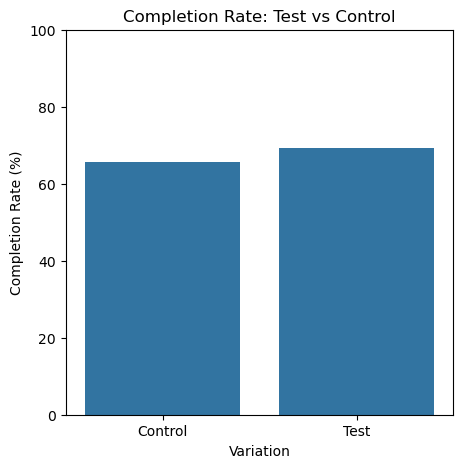

In [43]:
plt.figure(figsize=(5, 5))
sns.barplot(x=completion_rate.index, y=completion_rate.values)
plt.title("Completion Rate: Test vs Control")
plt.xlabel("Variation")
plt.ylabel("Completion Rate (%)")
plt.ylim(0, 100)
plt.show()

#### 2. Time spent per step

In [85]:
# KPI 2: Time Spent on Each Step (including back-and-forth)

# Calculate time duration per step
web_merged = web_merged.sort_values(by=["visit_id", "date_time"]).reset_index(drop=True)
web_merged["time_spent_sec"] = (
    web_merged.groupby("visit_id")["date_time"].diff().dt.total_seconds()
)

# Filter valid time values
valid_time_df = web_merged[(web_merged["time_spent_sec"] > 0)]

# ---------------------------------------------------------
# Aggregate: SUM all time per visit_id + process_step
# ---------------------------------------------------------
# This captures ALL time spent on each step, including revisits
# Gives a more complete picture of user engagement per step
time_per_step = (
    valid_time_df.groupby(["visit_id", "Variation", "process_step"])["time_spent_sec"]
    .sum()  # Sum ALL occurrences of this step for this user
    .reset_index()
)

# ---------------------------------------------------------
# Summary statistics
# ---------------------------------------------------------
time_spent_summary = (
    time_per_step.groupby(["Variation", "process_step"])["time_spent_sec"]
    .agg(
        mean_time_sec="mean",
        median_time_sec="median",
    )
    .round(2)
)

print("=== KPI 2: TIME SPENT PER STEP (SECONDS) ===")
print(time_spent_summary)

=== KPI 2: TIME SPENT PER STEP (SECONDS) ===
                        mean_time_sec  median_time_sec
Variation process_step                                
Control   confirm              140.20             78.0
          start                307.33            108.0
          step_1                54.16             22.0
          step_2                49.70             25.0
          step_3               115.83             80.0
Test      confirm              150.36             60.0
          start                279.46            120.0
          step_1                51.63             14.0
          step_2                60.86             28.0
          step_3               113.08             74.0


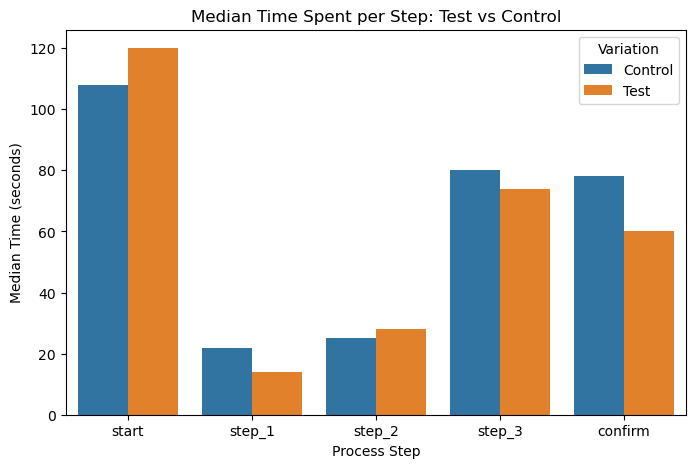

In [79]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=time_spent_summary.reset_index(),
    x="process_step",
    y="median_time_sec",
    hue="Variation",
    order=step_order
)
plt.title("Median Time Spent per Step: Test vs Control")
plt.xlabel("Process Step")
plt.ylabel("Median Time (seconds)")
plt.show()

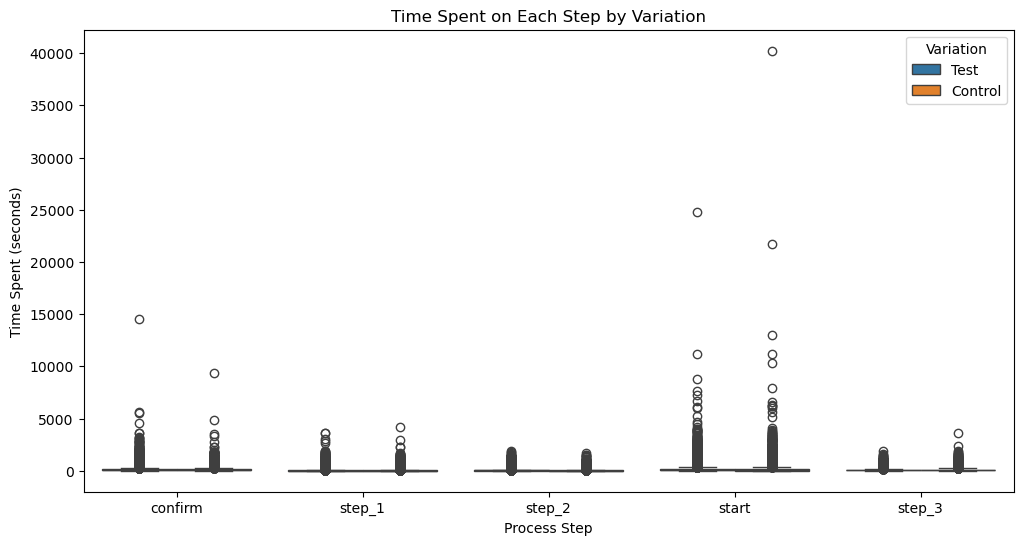

In [80]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=valid_time_df,
    x="process_step",
    y="time_spent_sec",
    hue="Variation"
)

plt.title("Time Spent on Each Step by Variation")
plt.xlabel("Process Step")
plt.ylabel("Time Spent (seconds)")
plt.legend(title="Variation")
plt.show()


Just to avoid taking any arbitrary decision, we will calculate upper and lower bounds so we can have better insights of the time spent in each step, with an additional constraint that time cannot be negative.

In [81]:
# ---------------------------------------------------------
# 1. Filter to valid (positive) time values
# ---------------------------------------------------------
# Time cannot be negative, so we first restrict the data
# to rows where time_spent_sec > 0.
time_df = web_merged[web_merged["time_spent_sec"] > 0].copy()

# ---------------------------------------------------------
# 2. Compute IQR-based outlier bounds
# ---------------------------------------------------------
# Interquartile range (IQR) method:
#   - Q1: 25th percentile
#   - Q3: 75th percentile
#   - IQR = Q3 - Q1
# Outliers are typically defined as:
#   - Below Q1 - 1.5 * IQR
#   - Above Q3 + 1.5 * IQR
q1 = time_df["time_spent_sec"].quantile(0.25)
q3 = time_df["time_spent_sec"].quantile(0.75)
iqr = q3 - q1

lower_bound_iqr = q1 - 1.5 * iqr
upper_bound_iqr = q3 + 1.5 * iqr

# ---------------------------------------------------------
# 3. Enforce domain constraint: time >= 0
# ---------------------------------------------------------
# The IQR formula can produce a negative lower bound,
# but time_spent_sec cannot be negative. We therefore
# clamp the lower bound at 0.
lower_bound = max(0, lower_bound_iqr)
upper_bound = upper_bound_iqr

# ---------------------------------------------------------
# 4. Filter out outliers
# ---------------------------------------------------------
# Keep only rows where time_spent_sec is within the
# adjusted [lower_bound, upper_bound] interval.
valid_time_df = time_df[
    (time_df["time_spent_sec"] >= lower_bound) &
    (time_df["time_spent_sec"] <= upper_bound)
].copy()

# ---------------------------------------------------------
# 5. Inspect the resulting bounds
# ---------------------------------------------------------
print(f"Lower bound (adjusted): {lower_bound}")
print(f"Upper bound: {upper_bound}")


Lower bound (adjusted): 0
Upper bound: 188.0


In [82]:
# ---------------------------------------------------------
# Summary statistics (using aggregated per-step data)
# ---------------------------------------------------------
time_spent_summary2 = (
    time_per_step.groupby(["Variation", "process_step"])["time_spent_sec"]
    .agg(
        mean_time_sec="mean",
        median_time_sec="median",
    )
    .round(2)
)

print(time_spent_summary2)



                        mean_time_sec  median_time_sec
Variation process_step                                
Control   confirm              140.20             78.0
          start                307.33            108.0
          step_1                54.16             22.0
          step_2                49.70             25.0
          step_3               115.83             80.0
Test      confirm              150.36             60.0
          start                279.46            120.0
          step_1                51.63             14.0
          step_2                60.86             28.0
          step_3               113.08             74.0


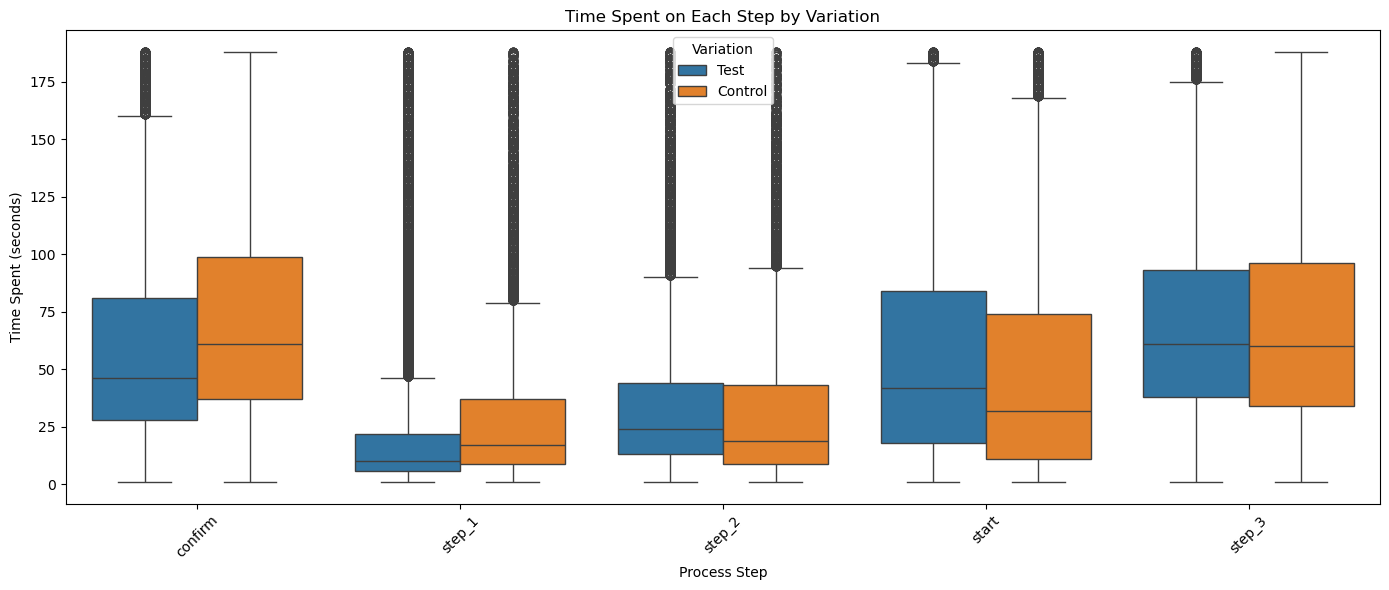

In [83]:
from matplotlib import pyplot as plt

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=valid_time_df,
    x="process_step",
    y="time_spent_sec",
    hue="Variation"
)

plt.title("Time Spent on Each Step by Variation")
plt.xlabel("Process Step")
plt.ylabel("Time Spent (seconds)")
plt.legend(title="Variation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


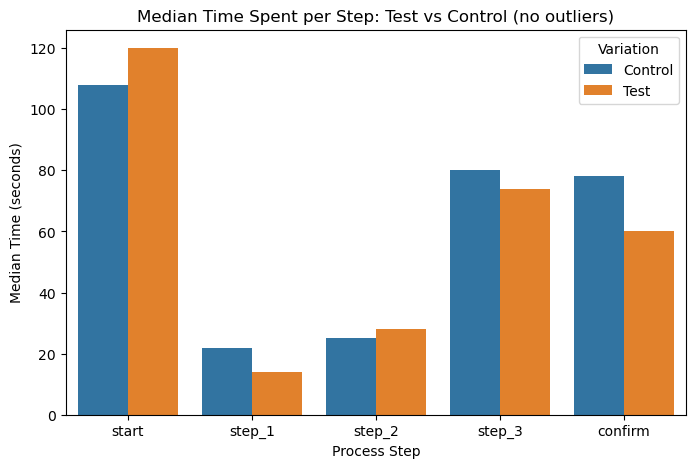

In [84]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=time_spent_summary2.reset_index(),
    x="process_step",
    y="median_time_sec",
    hue="Variation",
    order=step_order
)
plt.title("Median Time Spent per Step: Test vs Control (no outliers)")
plt.xlabel("Process Step")
plt.ylabel("Median Time (seconds)")
plt.show()

#### 3. Error rate

In [91]:
# 4. KPI 3: Error Rate (Backward Navigation)

# Map process steps to sequential numerical order
step_map = {"start": 1, "step_1": 2, "step_2": 3, "step_3": 4, "confirm": 5}
web_merged["step_order"] = web_merged["process_step"].map(step_map)

# Identify the next step order within the same visit session
web_merged["next_step_order"] = web_merged.groupby("visit_id")[
    "step_order"
].shift(-1)

# Flag backward movement (going back to a lower step order = user error / confusion)
web_merged["is_error"] = (
    web_merged["next_step_order"] < web_merged["step_order"]
)

# Calculate Error Rate percentage for each variation
error_summary = web_merged.groupby("Variation").agg(
    total_step_events=("process_step", "count"),
    error_events=("is_error", "sum"),
)

error_summary["error_rate (%)"] = (
    error_summary["error_events"] / error_summary["total_step_events"] * 100
).round(2)

print("=== KPI 3: ERROR RATE (BACKWARD NAVIGATION) ===")
print(error_summary)



=== KPI 3: ERROR RATE (BACKWARD NAVIGATION) ===
           total_step_events  error_events  error_rate (%)
Variation                                                 
Control               140536          9682            6.89
Test                  176699         16358            9.26


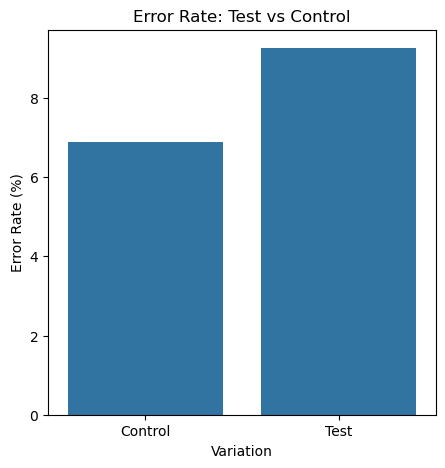

In [52]:
plt.figure(figsize=(5, 5))
sns.barplot(x=error_summary.index, y=error_summary["error_rate (%)"])
plt.title("Error Rate: Test vs Control")
plt.xlabel("Variation")
plt.ylabel("Error Rate (%)")
plt.show()

Error rate is higher in test group than in control group. This can be explained as is a new system and perhaps users are not used to the new interface.

#### Other KPIs

Other potential KPIS are:

- 1. Step-to-step drop-off rate (not just overall completion)
    "X% of people who reached step_2 never made it to step_3". (clients at step N) / (clients at step N-1) for each transition, per Variation
- 2. Total time-to-complete (start → confirm) per visit
    Different from time-per-step: this is the whole journey duration for clients who actually finished.
- 3. Steps taken per visit (process efficiency)
    Count total step-events per visit_id (including backward moves).
- 4. Repeat-visit rate
    Some clients may need more than one visit_id/session to reach confirm. Count distinct visits per client_id and see what % of clients needed 2+ attempts, by group.
- 5. [DONE]Completion rate segmented by demographics 
    Interesting to see the U group
- 6. Start-step bounce rate [not relevant]
    A narrower version of #1: what % of clients who land on start never move to step_1 at all.

#### Completion rate per age

Goal: check whether the new design (Test) helps some age groups more than others, rather than just looking at the overall completion rate across all clients combined.

In [104]:
# --- Build client_summary: one row per client, with completion status + demographics ---

# Did each client ever reach "confirm"?
client_completed = (
    web_merged.groupby("client_id")["process_step"]
    .apply(lambda steps: "confirm" in steps.values)
    .reset_index(name="completed")
)

# Attach Variation and demographics from df_merged (client-level table you already built)
client_summary = client_completed.merge(
    df_merged[["client_id", "Variation", "clnt_age", "clnt_tenure_yr"]],
    on="client_id",
    how="left"
)

client_summary.head()

,client_id,completed,Variation,clnt_age,clnt_tenure_yr
0,555,True,Test,29.5,3.0
1,647,True,Test,57.5,12.0
2,934,False,Test,51.0,9.0
3,1028,False,Control,36.0,12.0
4,1104,False,Control,48.0,5.0


  Variation age_group  completion_rate_pct  num_clients
0   Control       <30                65.94         4190
1   Control     30-45                67.48         6347
2   Control     46-60                66.71         7320
3   Control       60+                61.72         5669
4      Test       <30                72.24         4871
5      Test     30-45                70.28         7446
6      Test     46-60                68.53         8278
7      Test       60+                66.87         6366


/var/folders/b4/svxttqvs5zg_rg_drrxn_vf00000gn/T/ipykernel_87698/302299561.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  client_summary.groupby(["Variation", "age_group"])["client_id"]
/var/folders/b4/svxttqvs5zg_rg_drrxn_vf00000gn/T/ipykernel_87698/302299561.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  client_summary.groupby(["Variation", "age_group"])["completed"]


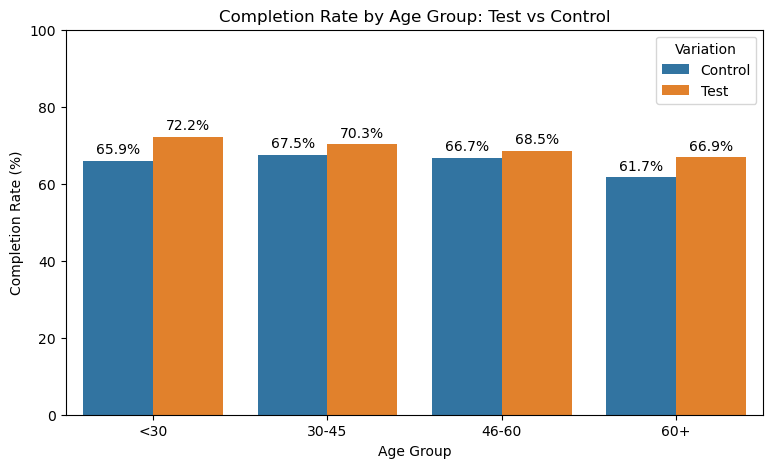

In [105]:
# --- Step 1: Create age buckets ---
# Split continuous age into discrete groups so we can compare
# completion rate per bucket instead of per individual age.
bins = [0, 30, 45, 60, 100]          # boundaries between buckets
labels = ["<30", "30-45", "46-60", "60+"]  # names for each bucket

# pd.cut assigns each client's age to one of the buckets above.
# Example: age 52 -> falls between 45 and 60 -> labeled "46-60"
client_summary["age_group"] = pd.cut(
    client_summary["clnt_age"], bins=bins, labels=labels
)

# --- Step 2: Also capture group size (sample size) per bucket ---
# Important: some age groups may have very few clients, which
# makes their completion rate unreliable (a rate based on 12
# people swings wildly vs one based on 5,000 people). We track
# this so we don't over-interpret small groups later.
group_sizes = (
    client_summary.groupby(["Variation", "age_group"])["client_id"]
    .count()
    .reset_index(name="num_clients")
)

# --- Step 3: Calculate completion rate per Variation + age group ---
# "completed" is a True/False column, so .mean() on it gives the
# proportion of True values, i.e. the completion rate.
completion_by_age = (
    client_summary.groupby(["Variation", "age_group"])["completed"]
    .mean()                # proportion who completed (0 to 1)
    .mul(100)               # convert to a percentage
    .round(2)
    .reset_index(name="completion_rate_pct")
)

# --- Step 4: Merge in the sample sizes so we can see both
# the rate AND how many people that rate is based on ---
completion_by_age = completion_by_age.merge(
    group_sizes, on=["Variation", "age_group"], how="left"
)

print(completion_by_age)

# --- Step 5: Plot completion rate by age group, split by Variation ---
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=completion_by_age,
    x="age_group",
    y="completion_rate_pct",
    hue="Variation",
    order=labels  # force <30, 30-45, 46-60, 60+ order (not alphabetical)
)

# Add % labels on top of each bar for readability
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Completion Rate by Age Group: Test vs Control")
plt.xlabel("Age Group")
plt.ylabel("Completion Rate (%)")
plt.ylim(0, 100)
plt.show()

Test group have higher completion rate vs control group, independently of the age group.

#### Step-to-step drop-off rate

Let's calculate what % of people who reached step N-1 did not make it to step N. Also, let's calculate the cumulative so we can have the bigger picture.


In [112]:
# ============================================================
# KPI 1: Step-to-step DROP-OFF rate
# (what % of people who reached step N-1 did NOT make it to step N)
# ============================================================

# Count unique clients reaching each step, per Variation
step_counts = (
    web_merged.groupby(["Variation", "process_step"])["client_id"]
    .nunique()
    .reset_index(name="unique_clients")
)

# Force the correct step order (start -> confirm) instead of
# alphabetical sorting
step_counts["process_step"] = pd.Categorical(
    step_counts["process_step"], categories=step_order, ordered=True
)
step_counts = step_counts.sort_values(["Variation", "process_step"])

# For each Variation, shift unique_clients down by one row to get
# "how many clients were at the PREVIOUS step"
step_counts["prev_step_clients"] = step_counts.groupby("Variation")["unique_clients"].shift(1)

# Drop-off rate = clients who did NOT make it to this step, as a %
# of clients who were at the previous step
step_counts["dropoff_rate_pct"] = (
    (1 - step_counts["unique_clients"] / step_counts["prev_step_clients"]) * 100
).round(2)

# Remove "start" — it has no previous step to have dropped off from
step_counts = step_counts[step_counts["process_step"] != "start"]
step_counts["process_step"] = step_counts["process_step"].cat.remove_unused_categories()

# ---------------------------------------------------------
# KPI 1b: CUMULATIVE DROP-OFF rate
# (what % of users who STARTED never made it to this step)
# ---------------------------------------------------------
# Get the number of users who started per Variation
start_counts = (
    web_merged[web_merged["process_step"] == "start"]
    .groupby("Variation")["client_id"]
    .nunique()
    .reset_index(name="started_clients")
)

# Merge start counts back to step_counts
step_counts = step_counts.merge(start_counts, on="Variation", how="left")

# Cumulative drop-off = % of starters who NEVER reached this step
step_counts["cumulative_dropoff_pct"] = (
    (1 - step_counts["unique_clients"] / step_counts["started_clients"]) * 100
).round(2)

# Print the table with both metrics
print(step_counts[["Variation", "process_step", "unique_clients", "started_clients", "dropoff_rate_pct", "cumulative_dropoff_pct"]])


  Variation process_step  unique_clients  started_clients  dropoff_rate_pct  \
0   Control       step_1           20152            23397             13.87   
1   Control       step_2           18650            23397              7.45   
2   Control       step_3           17422            23397              6.58   
3   Control      confirm           15434            23397             11.41   
4      Test       step_1           24267            26679              9.04   
5      Test       step_2           22258            26679              8.28   
6      Test       step_3           20881            26679              6.19   
7      Test      confirm           18687            26679             10.51   

   cumulative_dropoff_pct  
0                   13.87  
1                   20.29  
2                   25.54  
3                   34.03  
4                    9.04  
5                   16.57  
6                   21.73  
7                   29.96  


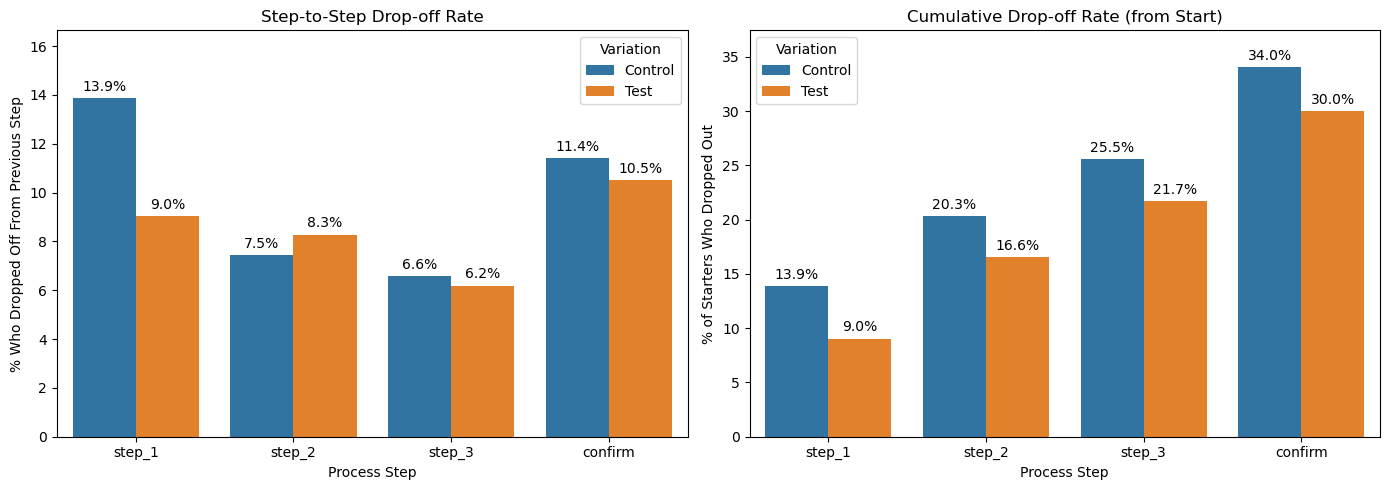

In [113]:
# Plot both step-to-step and cumulative drop-off
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Step-to-step drop-off
sns.barplot(data=step_counts, x="process_step", y="dropoff_rate_pct", hue="Variation", ax=axes[0])
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.1f%%", padding=3)
axes[0].set_title("Step-to-Step Drop-off Rate")
axes[0].set_xlabel("Process Step")
axes[0].set_ylabel("% Who Dropped Off From Previous Step")
axes[0].set_ylim(0, max(step_counts["dropoff_rate_pct"].max() * 1.2, 15))
axes[0].legend(title="Variation")

# Right: Cumulative drop-off
sns.barplot(data=step_counts, x="process_step", y="cumulative_dropoff_pct", hue="Variation", ax=axes[1])
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f%%", padding=3)
axes[1].set_title("Cumulative Drop-off Rate (from Start)")
axes[1].set_xlabel("Process Step")
axes[1].set_ylabel("% of Starters Who Dropped Out")
axes[1].set_ylim(0, max(step_counts["cumulative_dropoff_pct"].max() * 1.1, 35))
axes[1].legend(title="Variation")

plt.tight_layout()
plt.show()


# Phase 3 — Hypothesis Testing

### Completion rate - Statistical significance

For the statistical analysis, we're going to use the Two-Proportion Z-Test.

The Two-Proportion Z-Test is a parametric test that compares whether two independent groups have significantly different proportions (percentages).

 **Why Two-Proportion Z-Test (not other tests)?**
 - Outcome is BINARY (completed vs not completed) - we're comparing proportions, not means
 - Large sample sizes (n > 30 per group) - normal approximation is valid
 - Standard test for A/B testing conversion rates
 - More interpretable than Chi-square for two groups (gives directionality)

 **Hypotheses definition**

 **H₀**: Completion rate in Test = Completion rate in Control (rates are equal)

 **H₁**: Completion rate in Test ≠ Completion rate in Control (rates differ)


In [100]:
# Difference between groups
diff_abs = completion_rate["Test"] - completion_rate["Control"]
diff_relative = (diff_abs / completion_rate["Control"]) * 100

print(f"Completion rate difference between groups is: {diff_abs:+.2f}%")
print(f"Relative difference: {diff_relative:+.2f}%")
print()
# counts of clients who completed vs total clients per group
count = np.array([completed_clients["Test"], completed_clients["Control"]])
nobs = np.array([total_clients["Test"], total_clients["Control"]])

z_stat, p_value = proportions_ztest(count, nobs, alternative="two-sided")

print(f"z-statistic: {z_stat:.3f}")
print(f"p-value: {p_value:.5f}")
print()
alpha = 0.05
if p_value < alpha:
    print("Reject H₀: Completion rate is significantly different between groups.")
else:
    print("Fail to reject H₀: No significant difference in completion rate.")


Completion rate difference between groups is: +3.70%
Relative difference: +5.64%

z-statistic: 8.875
p-value: 0.00000

Reject H₀: Completion rate is significantly different between groups.


Test has significantly higher completion rate:
- Difference: +3.70 percentage points
- Relative increase: 5.64% vs Control
- p-value: < 0.00001 (highly significant)

Implication: Test users complete the funnel 5.64% more often than Control users, indicating improved conversion.

### Time spent per step - Statistical significance

For the statistican analysis, we're going to use Mann-Whitney.

Mann-Whitney U is a non-parametric test that compares whether two independent groups come from the same distribution.

 Why Mann-Whitney U (not t-test)?
 - Time data is typically right-skewed (not normally distributed as we have seen previously)
 - Robust to outliers (uses ranks instead of raw values)
 - Tests whether one group tends to have larger values than the other

**Hypotheses definition**

 **H₀**: Time spent distribution is the same in Test and Control

 **H₁**: Time spent distribution differs between groups

In [86]:
# ---------------------------------------------------------
# Statistical Significance Test: Mann-Whitney U (per step)
# ---------------------------------------------------------

# How it works:
# - Converts all time values to ranks (1st smallest, 2nd smallest, etc.)
# - Compares whether Test group tends to have higher ranks than Control
# - Does NOT assume normal distribution or equal variances
#
# Unit of analysis:
# - Each observation = one user's total time on a specific step
# - Includes ALL time spent on that step (including revisits/back-and-forth)
# - Observations are independent (one row per user-step combination)

print(f"\n=== STATISTICAL SIGNIFICANCE TEST (BY STEP) ===\n")

steps = time_per_step["process_step"].unique()

for step in steps:
    # Filter data for this specific step
    step_data = time_per_step[time_per_step["process_step"] == step]
    test_time = step_data[step_data["Variation"] == "Test"]["time_spent_sec"]
    control_time = step_data[step_data["Variation"] == "Control"]["time_spent_sec"]
    
    # Run Mann-Whitney U test (two-sided: tests for any difference)
    u_stat, p_value = mannwhitneyu(test_time, control_time, alternative="two-sided")
    
    # Get medians for interpretation
    test_median = test_time.median()
    control_median = control_time.median()
    
    # Print results
    print(f"{step.upper()}:")
    print(f"  U-statistic: {u_stat:.3f} | P-value: {p_value:.5f}")
    
    if p_value < 0.05:
        if test_median > control_median:
            print(f"  ✓ Significant: Test spends MORE time (median: {test_median:.1f}s vs {control_median:.1f}s)")
        else:
            print(f"  ✓ Significant: Test spends LESS time (median: {test_median:.1f}s vs {control_median:.1f}s)")
    else:
        print(f"  ✗ Not significant (median: Test={test_median:.1f}s, Control={control_median:.1f}s)")
    print()



=== STATISTICAL SIGNIFICANCE TEST (BY STEP) ===

CONFIRM:
  U-statistic: 126520722.500 | P-value: 0.00000
  ✓ Significant: Test spends LESS time (median: 60.0s vs 78.0s)

START:
  U-statistic: 55348338.500 | P-value: 0.00000
  ✓ Significant: Test spends MORE time (median: 120.0s vs 108.0s)

STEP_1:
  U-statistic: 269528128.500 | P-value: 0.00000
  ✓ Significant: Test spends LESS time (median: 14.0s vs 22.0s)

STEP_2:
  U-statistic: 264403909.500 | P-value: 0.00000
  ✓ Significant: Test spends MORE time (median: 28.0s vs 25.0s)

STEP_3:
  U-statistic: 188106683.500 | P-value: 0.00000
  ✓ Significant: Test spends LESS time (median: 74.0s vs 80.0s)



**Highlights: Time Spent Analysis**

Key Findings

Test users are FASTER on 3/5 steps:
- STEP_1: 14s vs 22s (−8s, 36% faster)
- CONFIRM: 60s vs 78s (−18s, 23% faster)
- STEP_3: 74s vs 80s (−6s, 8% faster)

Test users are SLOWER on 2/5 steps:
- START: 120s vs 108s (+12s, 11% slower)
- STEP_2: 28s vs 25s (+3s, 12% slower)

Bottom Line

- Improvement: Test users move ~17s faster through the funnel overall
- To investigate: START step takes 12s longer - could be more engagement OR confusion

All differences are significant (p < 0.0001) 

### Error rate - Statistical significance

For this KPI we're use again two proportion Z test again, as we have used before to compare proportions.

**Hypotheses definition**

 **H₀**: Error rate in Test = Error rate in Control (rates are equal)

 **H₁**: Error rate in Test ≠ Error rate in Control (rates differ)

In [95]:
# Difference in error rates
error_rate_diff = error_summary.loc["Test", "error_rate (%)"] - error_summary.loc["Control", "error_rate (%)"]
print(f"\nError rate difference: {error_rate_diff:+.2f}%")

# Counts for z-test
count = np.array([
    error_summary.loc["Test", "error_events"],
    error_summary.loc["Control", "error_events"]
])
nobs = np.array([
    error_summary.loc["Test", "total_step_events"],
    error_summary.loc["Control", "total_step_events"]
])

z_stat, p_value = proportions_ztest(count, nobs, alternative="two-sided")

print(f"\nz-statistic: {z_stat:.3f}")
print(f"p-value: {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n✓ Accept H₁: Error rate is significantly different (p = {p_value:.5f})")
    if error_rate_diff > 0:
        print(f"  → Test has higher error rate (worse user experience)")
    else:
        print(f"  → Test has lower error rate (better user experience)")
else:
    print(f"\n✗ Accept H₀: No significant difference in error rate (p = {p_value:.5f})")



Error rate difference: +2.37%

z-statistic: 24.138
p-value: 0.00000

✓ Accept H₁: Error rate is significantly different (p = 0.00000)
  → Test has higher error rate (worse user experience)


Test has significantly higher error rate:
- Test: 9.26% vs Control: 6.89%
- Difference: +2.37 pp (34% increase)
- p-value: < 0.00001 (highly significant)

Implication: Test users make 34% more errors, suggesting more confusion. There is needed more investigation.

### Completion rate per age - Statistical significance

**Hypotheses definition**

- **H₀**: Completion rate in Test = Completion rate in Control, within this age group (rates are equal)
- **H₁**: Completion rate in Test ≠ Completion rate in Control, within this age group (rates differ)

For this we will test each group independently

In [106]:
print("=== STATISTICAL SIGNIFICANCE TEST: COMPLETION RATE BY AGE GROUP ===\n")

# Get the list of age buckets we defined earlier (<30, 30-45, 46-60, 60+)
age_groups = client_summary["age_group"].dropna().unique()

# Loop through each age bucket and run an independent test within it
for age_grp in age_groups:

    # Isolate just the clients that fall into this age bucket
    grp_data = client_summary[client_summary["age_group"] == age_grp]

    # Within this bucket: how many clients completed, and how many
    # total clients there are, broken down by Variation (Test/Control).
    # "completed" is True/False, so .sum() counts the Trues (= completions)
    # and .count() counts every row (= total clients in that group).
    completed_by_var = grp_data.groupby("Variation")["completed"].sum()
    total_by_var = grp_data.groupby("Variation")["completed"].count()

    # Safety check: if this age bucket happens to have zero clients in
    # either Test or Control (unlikely here, but good practice), skip it
    # rather than crashing on a missing key.
    if "Test" not in total_by_var or "Control" not in total_by_var:
        print(f"{age_grp}: skipped (missing Test or Control clients in this bucket)\n")
        continue

    # proportions_ztest expects two arrays:
    #   count = number of "successes" (completions) in each group
    #   nobs  = total number of observations (clients) in each group
    count = np.array([completed_by_var["Test"], completed_by_var["Control"]])
    nobs = np.array([total_by_var["Test"], total_by_var["Control"]])

    # Run the two-sided z-test: are the two proportions different at all
    # (regardless of direction)? This matches the two-sided H1 above.
    z_stat, p_value = proportions_ztest(count, nobs, alternative="two-sided")

    # Convert raw counts into % completion rates, just for readability
    # in the printed output (the test itself already used the raw counts).
    test_rate = completed_by_var["Test"] / total_by_var["Test"] * 100
    control_rate = completed_by_var["Control"] / total_by_var["Control"] * 100

    # --- Report results for this age bucket ---
    # n_Test / n_Control are printed alongside the rates so we can judge
    # how much weight to give a "significant" or "not significant" result —
    # a small n makes it harder to detect a real effect, and easier for
    # a fluke difference to look significant.
    print(f"{age_grp}  (n_Test={total_by_var['Test']}, n_Control={total_by_var['Control']})")
    print(f"  Completion rate — Test: {test_rate:.2f}% | Control: {control_rate:.2f}%")
    print(f"  z-statistic: {z_stat:.3f} | p-value: {p_value:.5f}")

    # Standard alpha = 0.05 threshold, consistent with the rest of your
    # Phase 3 tests, so all your hypothesis tests use the same significance
    # bar and are comparable to each other.
    if p_value < 0.05:
        # p < 0.05 -> reject H0 -> the difference we see is unlikely to be
        # due to chance alone. Report which group actually did better.
        winner = "Test" if test_rate > control_rate else "Control"
        print(f"  → Reject H0: significant difference, {winner} performs better in this age group\n")
    else:
        # p >= 0.05 -> fail to reject H0 -> not enough evidence to say the
        # two groups differ in this bucket (could be a real null effect,
        # or could just be an underpowered sample — see n_Test/n_Control above).
        print(f"  → Fail to reject H0: no significant difference in this age group\n")

=== STATISTICAL SIGNIFICANCE TEST: COMPLETION RATE BY AGE GROUP ===

<30  (n_Test=4871, n_Control=4190)
  Completion rate — Test: 72.24% | Control: 65.94%
  z-statistic: 6.485 | p-value: 0.00000
  → Reject H0: significant difference, Test performs better in this age group

46-60  (n_Test=8278, n_Control=7320)
  Completion rate — Test: 68.53% | Control: 66.71%
  z-statistic: 2.430 | p-value: 0.01510
  → Reject H0: significant difference, Test performs better in this age group

30-45  (n_Test=7446, n_Control=6347)
  Completion rate — Test: 70.28% | Control: 67.48%
  z-statistic: 3.542 | p-value: 0.00040
  → Reject H0: significant difference, Test performs better in this age group

60+  (n_Test=6366, n_Control=5669)
  Completion rate — Test: 66.87% | Control: 61.72%
  z-statistic: 5.891 | p-value: 0.00000
  → Reject H0: significant difference, Test performs better in this age group



**Key takeaways:**

- Younger clients are probably more comfortable with modern UI patterns generally, so the redesign resonates strongly with them.
- Older clients (60+) may have been the ones struggling most with the old interface — so a more intuitive design closes an accessibility gap that used to hold them back.
- Middle-aged clients were likely already reasonably comfortable navigating the old process (consistent with your earlier finding that they're the long-tenured "primary" client base), so they have less room to improve — but the fact they still improve significantly means the new design isn't just helping newcomers, it's a genuine upgrade for everyone.

### Step-to-step drop-off rate - Statistical significance

TEST CHOICE: Chi-square test of independence

 Why this test?
 - Comparing proportions (drop-off vs continued) between two groups
 - Each user at a step is either: dropped off OR continued to next step
 - Large sample sizes - chi-square approximation is valid
 - Tests whether drop-off rate differs between Test and Control

Hypotheses (for each step):
- H₀: Drop-off rate Test = drop off rate in Control
- H₁: Drop-off rate Test ≠ drop off rate in Control

In [118]:
# ---------------------------------------------------------
# Statistical Significance Test: Chi-Square Test (per step)
# ---------------------------------------------------------
from scipy.stats import chi2_contingency

print("=" * 70)
print("STATISTICAL SIGNIFICANCE TEST: DROP-OFF RATES (BY STEP)")
print("=" * 70)

steps = step_counts["process_step"].unique()

for step in steps:
    step_data = step_counts[step_counts["process_step"] == step]
    
    # Get counts for each variation
    test_unique = step_data[step_data["Variation"] == "Test"]["unique_clients"].values[0]
    test_prev = step_data[step_data["Variation"] == "Test"]["prev_step_clients"].values[0]
    control_unique = step_data[step_data["Variation"] == "Control"]["unique_clients"].values[0]
    control_prev = step_data[step_data["Variation"] == "Control"]["prev_step_clients"].values[0]
    
    # Build contingency table
    continued_test = test_unique
    dropped_test = int(test_prev) - test_unique
    
    continued_control = control_unique
    dropped_control = int(control_prev) - control_unique
    
    contingency_table = [
        [continued_test, dropped_test],
        [continued_control, dropped_control]
    ]
    
    # Run chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # Calculate drop-off rates
    test_dropoff = (dropped_test / int(test_prev)) * 100
    control_dropoff = (dropped_control / int(control_prev)) * 100
    
    # Print results
    print(f"\n{step.upper()}:")
    print(f"  Drop-off rate: Test {test_dropoff:.2f}% vs Control {control_dropoff:.2f}%")
    print(f"  Chi-square: {chi2:.3f} | P-value: {p_value:.5f}")
    
    if p_value < 0.05:
        if test_dropoff < control_dropoff:
            print(f"  ✓ Significant: Test has LOWER drop-off")
        else:
            print(f"  ✓ Significant: Test has HIGHER drop-off")
    else:
        print(f"  ✗ Not significant")

STATISTICAL SIGNIFICANCE TEST: DROP-OFF RATES (BY STEP)

STEP_1:
  Drop-off rate: Test 9.04% vs Control 13.87%
  Chi-square: 289.537 | P-value: 0.00000
  ✓ Significant: Test has LOWER drop-off

STEP_2:
  Drop-off rate: Test 8.28% vs Control 7.45%
  Chi-square: 10.190 | P-value: 0.00141
  ✓ Significant: Test has HIGHER drop-off

STEP_3:
  Drop-off rate: Test 6.19% vs Control 6.58%
  Chi-square: 2.628 | P-value: 0.10497
  ✗ Not significant

CONFIRM:
  Drop-off rate: Test 10.51% vs Control 11.41%
  Chi-square: 7.882 | P-value: 0.00499
  ✓ Significant: Test has LOWER drop-off


**Key takeaways**

Test reduces drop-off rate at step_1 and confirmation, but has slightly higher drop-off at step_2. In step_3, no differences were observed.Overall, Test shows better retention.

### Important note

Given the number of tests run across time-spent, age-group, and drop-off comparisons, a Bonferroni correction would set a stricter threshold per test (e.g. α=0.01 for the 5-way time comparison). Nearly all our results remain significant even under this stricter bar, with the exception of the 46-60 age-group completion rate difference (p=0.0151), which would no longer be significant at the corrected threshold.